In [1]:
import json, zipfile, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from google.colab import files
uploaded = files.upload()
print("Uploaded:", list(uploaded.keys()))

Saving ipl_male_json.zip to ipl_male_json.zip
Saving odis_male_json.zip to odis_male_json.zip
Saving t20s_male_json.zip to t20s_male_json.zip
Saving tests_male_json.zip to tests_male_json.zip
Uploaded: ['ipl_male_json.zip', 'odis_male_json.zip', 't20s_male_json.zip', 'tests_male_json.zip']


In [3]:
DATA_DIR = Path("/content/cricsheet_data")
DATA_DIR.mkdir(exist_ok=True)

zip_files = {
    "tests_male_json.zip": "TEST",
    "odis_male_json.zip": "ODI",
    "t20s_male_json.zip": "T20",
    "ipl_male_json.zip": "IPL"
}

for filename, fmt in zip_files.items():
    if Path(filename).exists():
        out = DATA_DIR / fmt
        out.mkdir(exist_ok=True)
        with zipfile.ZipFile(filename) as z:
            z.extractall(out)
        print(fmt, "extracted")
    else:
        print("Missing:", filename)

TEST extracted
ODI extracted
T20 extracted
IPL extracted


In [4]:
def get_teams(info):
    teams = info.get("teams", [])
    return (teams[0] if len(teams) > 0 else None,
            teams[1] if len(teams) > 1 else None)

def get_toss(info):
    toss = info.get("toss", {})
    return toss.get("winner"), toss.get("decision")

def get_outcome(info):
    outcome = info.get("outcome", {})
    if outcome.get("winner"):
        return outcome["winner"], "winner"
    if outcome.get("result"):
        return None, outcome["result"]
    if "draw" in outcome:
        return None, "draw"
    return None, "unknown"

def get_totals(match, team1, team2):
    totals = {team1: [0, 0], team2: [0, 0]}
    for inning in match.get("innings", []):
        team = inning.get("team")
        if team not in totals:
            continue
        for over in inning.get("overs", []):
            for delivery in over.get("deliveries", []):
                totals[team][0] += delivery.get("runs", {}).get("total", 0)
                for wicket in delivery.get("wickets", []):
                    if str(wicket.get("kind", "")).lower() not in {"retired hurt", "retired not out"}:
                        totals[team][1] += 1
    return (*totals.get(team1, [0,0]), *totals.get(team2, [0,0]))

def parse_match(path, fmt):
    with open(path, encoding="utf-8") as f:
        match = json.load(f)
    info = match.get("info", {})
    team1, team2 = get_teams(info)
    toss_winner, toss_decision = get_toss(info)
    winner, result = get_outcome(info)
    r1, r2, w1, w2 = get_totals(match, team1, team2)
    dates = info.get("dates", [])
    date = dates[0] if isinstance(dates, list) and dates else dates
    return {
        "format": fmt, "date": str(date) if date else None,
        "team1": team1, "team2": team2, "venue": info.get("venue"),
        "toss_winner": toss_winner, "toss_decision": toss_decision,
        "winner": winner, "result": result,
        "team1_runs": r1, "team2_runs": r2,
        "team1_wickets": w1, "team2_wickets": w2
    }

records = []
for fmt in ["TEST", "ODI", "T20", "IPL"]:
    paths = list((DATA_DIR / fmt).rglob("*.json"))
    print(fmt, "JSON files:", len(paths))
    for p in paths:
        try:
            records.append(parse_match(p, fmt))
        except Exception as e:
            print("Skipped", p.name, ":", e)

df = pd.DataFrame(records)
print("\nDataset shape:", df.shape)
display(df.head())

TEST JSON files: 894
ODI JSON files: 2571
T20 JSON files: 3539
IPL JSON files: 1243

Dataset shape: (8247, 13)


,format,date,team1,team2,venue,toss_winner,toss_decision,winner,result,team1_runs,team2_runs,team1_wickets,team2_wickets
0,TEST,2015-07-03,Sri Lanka,Pakistan,Pallekele International Cricket Stadium,Pakistan,field,Pakistan,winner,591,20,597,13
1,TEST,2019-08-30,West Indies,India,"Sabina Park, Jamaica",West Indies,field,India,winner,327,20,584,14
2,TEST,2016-05-27,England,Sri Lanka,Riverside Ground,England,bat,England,winner,578,10,576,20
3,TEST,2018-11-24,Pakistan,New Zealand,Dubai International Cricket Stadium,Pakistan,bat,Pakistan,winner,418,5,402,20
4,TEST,2003-12-18,England,Sri Lanka,"Sinhalese Sports Club Ground, Colombo",England,bat,Sri Lanka,winner,413,20,628,8


In [5]:
print("Records:", df.shape[0])
print("Features:", df.shape[1])
print("\nColumns:")
print(df.columns.tolist())

print("\nMatches by format:")
display(df["format"].value_counts())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nDuplicate records:", df.duplicated().sum())

Records: 8247
Features: 13

Columns:
['format', 'date', 'team1', 'team2', 'venue', 'toss_winner', 'toss_decision', 'winner', 'result', 'team1_runs', 'team2_runs', 'team1_wickets', 'team2_wickets']

Matches by format:


,count
format,
T20,3539
ODI,2571
IPL,1243
TEST,894



Data types:


,0
format,object
date,object
team1,object
team2,object
venue,object
toss_winner,object
toss_decision,object
winner,object
result,object
team1_runs,int64



Missing values:


,missing_count
winner,438
date,0
team1,0
team2,0
format,0
venue,0
toss_winner,0
toss_decision,0
result,0
team1_runs,0



Duplicate records: 0


In [6]:
print("Unique values per column:")
display(df.nunique().sort_values(ascending=False).to_frame("unique_values"))

print("Numerical statistical summary:")
display(df.describe())

print("Categorical statistical summary:")
display(df.describe(include="object"))

Unique values per column:


,unique_values
date,4697
team1_runs,735
team1_wickets,706
venue,476
team1,128
toss_winner,128
team2,126
winner,122
team2_runs,21
team2_wickets,21


Numerical statistical summary:


,team1_runs,team2_runs,team1_wickets,team2_wickets
count,8247.000000,8247.000000,8247.000000,8247.000000
mean,220.239117,7.883230,198.395780,7.420638
std,140.237862,4.036917,131.806809,4.461464
min,0.000000,0.000000,0.000000,0.000000
25%,140.000000,5.000000,125.000000,4.000000
50%,179.000000,8.000000,162.000000,7.000000
75%,249.000000,10.000000,227.000000,10.000000
max,1078.000000,20.000000,892.000000,20.000000


Categorical statistical summary:


,format,date,team1,team2,venue,toss_winner,toss_decision,winner,result
count,8247,8247,8247,8247,8247,8247,8247,7809,8247
unique,4,4697,128,126,476,128,2,122,4
top,T20,2026-05-16,India,Pakistan,Dubai International Cricket Stadium,England,field,India,winner
freq,3539,10,541,543,212,486,4349,601,7809


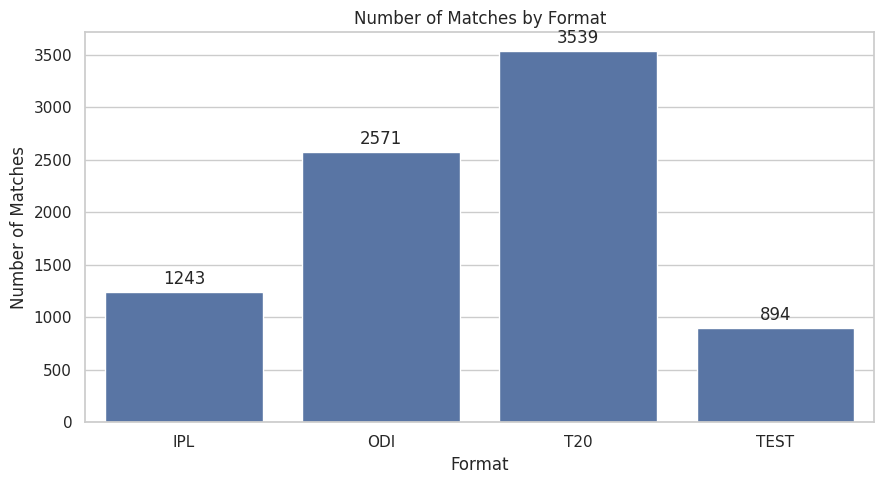

In [7]:
counts = df["format"].value_counts().reindex(["IPL","ODI","T20","TEST"]).dropna()
plt.figure(figsize=(9,5))
ax = sns.barplot(x=counts.index, y=counts.values)
plt.title("Number of Matches by Format")
plt.xlabel("Format"); plt.ylabel("Number of Matches")
for c in ax.containers: ax.bar_label(c, fmt="%.0f", padding=3)
plt.tight_layout(); plt.show()

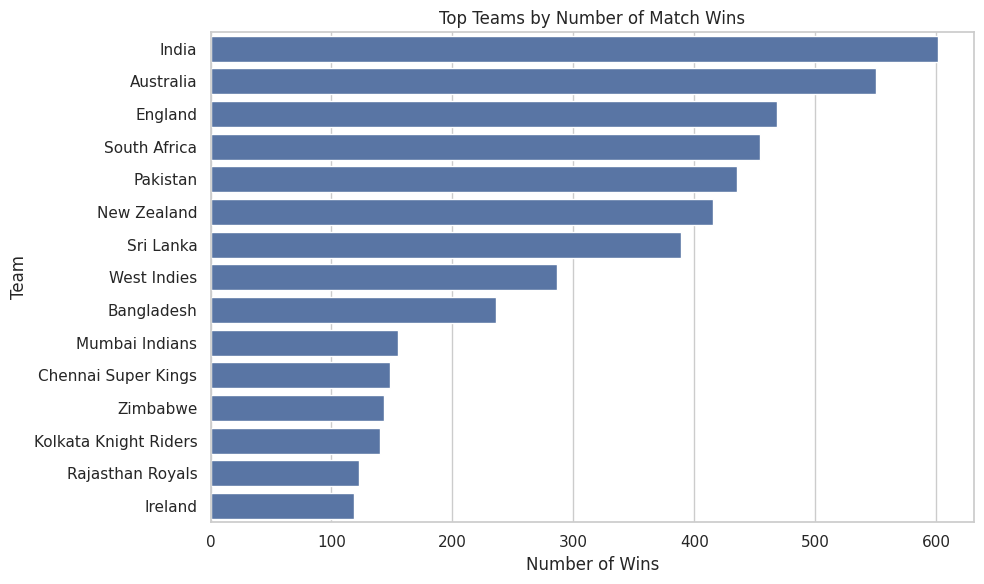

In [8]:
wins = df["winner"].dropna().value_counts().head(15)
plt.figure(figsize=(10,6))
sns.barplot(x=wins.values, y=wins.index)
plt.title("Top Teams by Number of Match Wins")
plt.xlabel("Number of Wins"); plt.ylabel("Team")
plt.tight_layout(); plt.show()

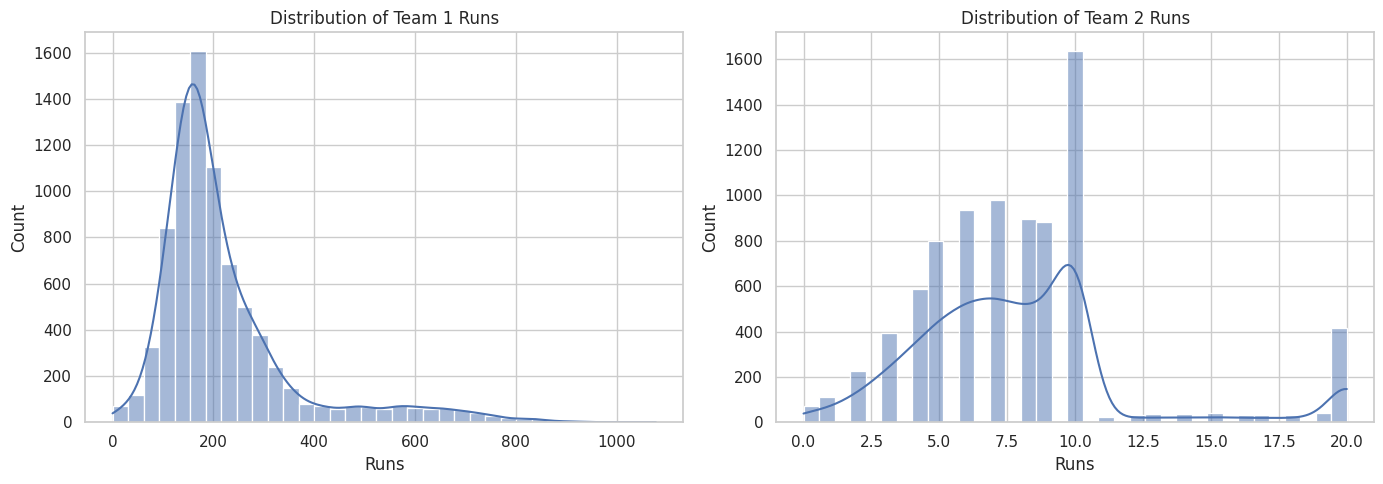

In [9]:
fig, ax = plt.subplots(1,2, figsize=(14,5))
sns.histplot(df["team1_runs"], bins=35, kde=True, ax=ax[0])
ax[0].set_title("Distribution of Team 1 Runs")
ax[0].set_xlabel("Runs")
sns.histplot(df["team2_runs"], bins=35, kde=True, ax=ax[1])
ax[1].set_title("Distribution of Team 2 Runs")
ax[1].set_xlabel("Runs")
plt.tight_layout(); plt.show()

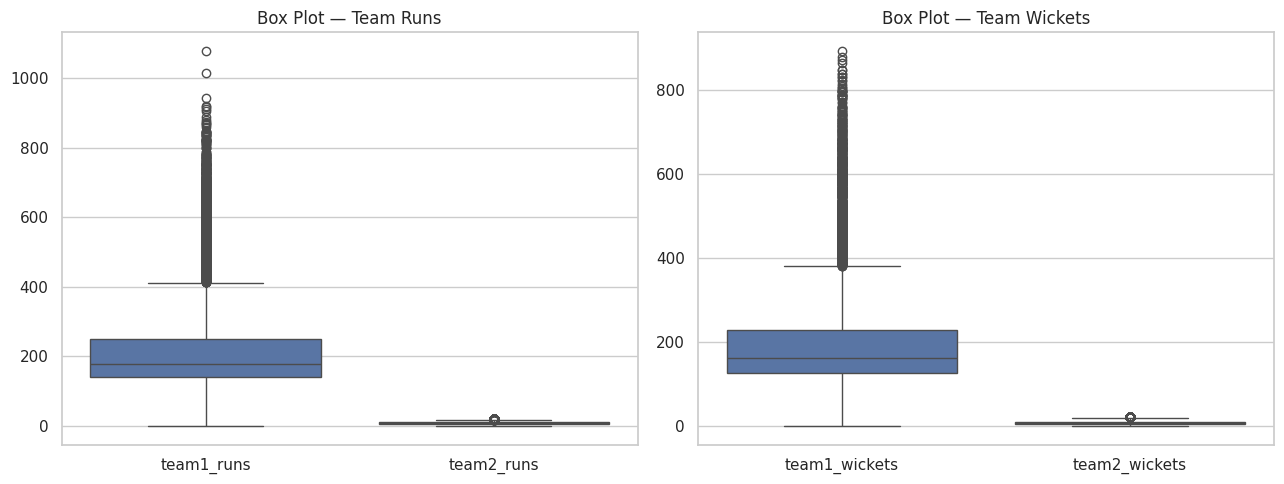

In [10]:
fig, ax = plt.subplots(1,2, figsize=(13,5))
sns.boxplot(data=df[["team1_runs","team2_runs"]], ax=ax[0])
ax[0].set_title("Box Plot — Team Runs")
sns.boxplot(data=df[["team1_wickets","team2_wickets"]], ax=ax[1])
ax[1].set_title("Box Plot — Team Wickets")
plt.tight_layout(); plt.show()

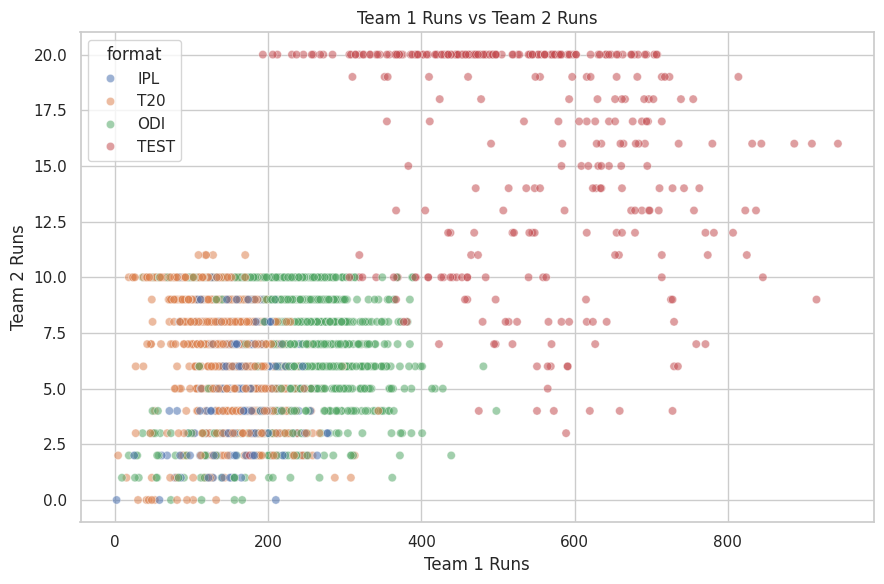

In [11]:
plot_df = df[(df["team1_runs"] > 0) | (df["team2_runs"] > 0)].copy()
sample = plot_df.sample(min(3000, len(plot_df)), random_state=42)
plt.figure(figsize=(9,6))
sns.scatterplot(data=sample, x="team1_runs", y="team2_runs", hue="format", alpha=.55)
plt.title("Team 1 Runs vs Team 2 Runs")
plt.xlabel("Team 1 Runs"); plt.ylabel("Team 2 Runs")
plt.tight_layout(); plt.show()

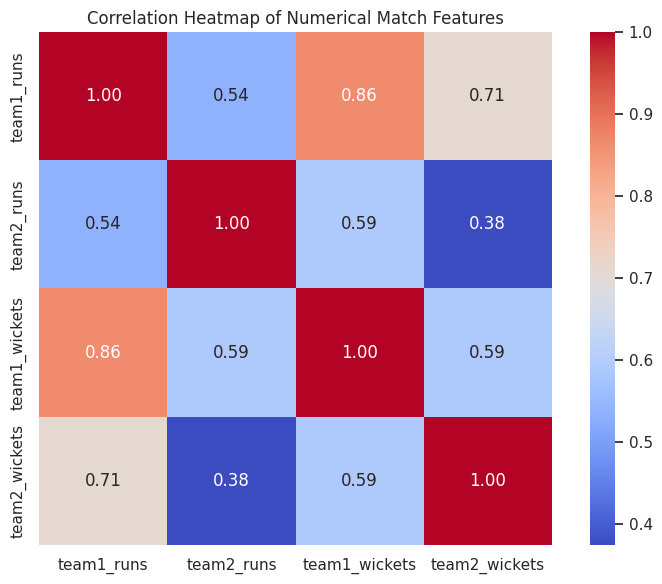

In [12]:
num_cols = ["team1_runs","team2_runs","team1_wickets","team2_wickets"]
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap of Numerical Match Features")
plt.tight_layout(); plt.show()

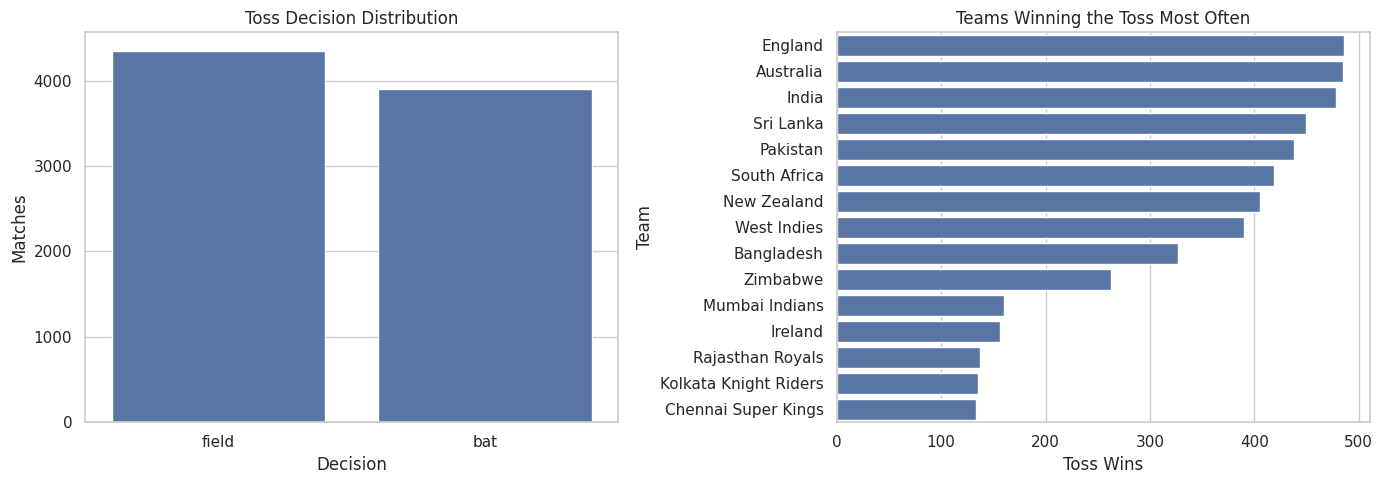

In [13]:
fig, ax = plt.subplots(1,2, figsize=(14,5))
toss_decision = df["toss_decision"].dropna().value_counts()
sns.barplot(x=toss_decision.index, y=toss_decision.values, ax=ax[0])
ax[0].set_title("Toss Decision Distribution")
ax[0].set_xlabel("Decision"); ax[0].set_ylabel("Matches")

toss_wins = df["toss_winner"].dropna().value_counts().head(15)
sns.barplot(x=toss_wins.values, y=toss_wins.index, ax=ax[1])
ax[1].set_title("Teams Winning the Toss Most Often")
ax[1].set_xlabel("Toss Wins"); ax[1].set_ylabel("Team")
plt.tight_layout(); plt.show()

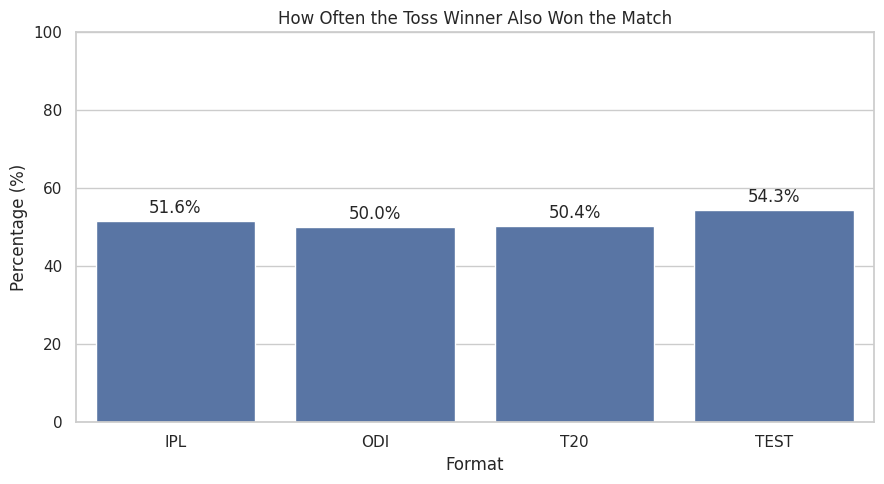

,Toss Winner Match Win %
format,
IPL,51.56
ODI,49.96
T20,50.38
TEST,54.34


In [14]:
toss_df = df.dropna(subset=["toss_winner","winner"]).copy()
toss_df["toss_winner_won_match"] = toss_df["toss_winner"] == toss_df["winner"]
rate = toss_df.groupby("format")["toss_winner_won_match"].mean().mul(100).round(2)

plt.figure(figsize=(9,5))
ax = sns.barplot(x=rate.index, y=rate.values)
plt.title("How Often the Toss Winner Also Won the Match")
plt.xlabel("Format"); plt.ylabel("Percentage (%)")
for c in ax.containers: ax.bar_label(c, fmt="%.1f%%", padding=3)
plt.ylim(0,100); plt.tight_layout(); plt.show()

display(rate.to_frame("Toss Winner Match Win %"))

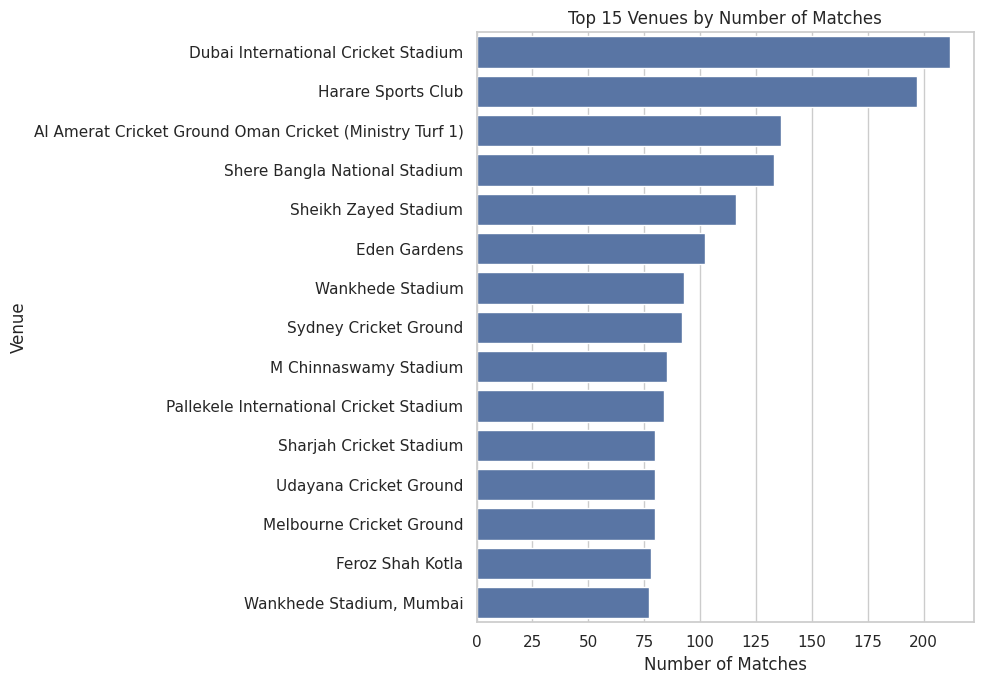

In [15]:
venues = df["venue"].dropna().value_counts().head(15)
plt.figure(figsize=(10,7))
sns.barplot(x=venues.values, y=venues.index)
plt.title("Top 15 Venues by Number of Matches")
plt.xlabel("Number of Matches"); plt.ylabel("Venue")
plt.tight_layout(); plt.show()

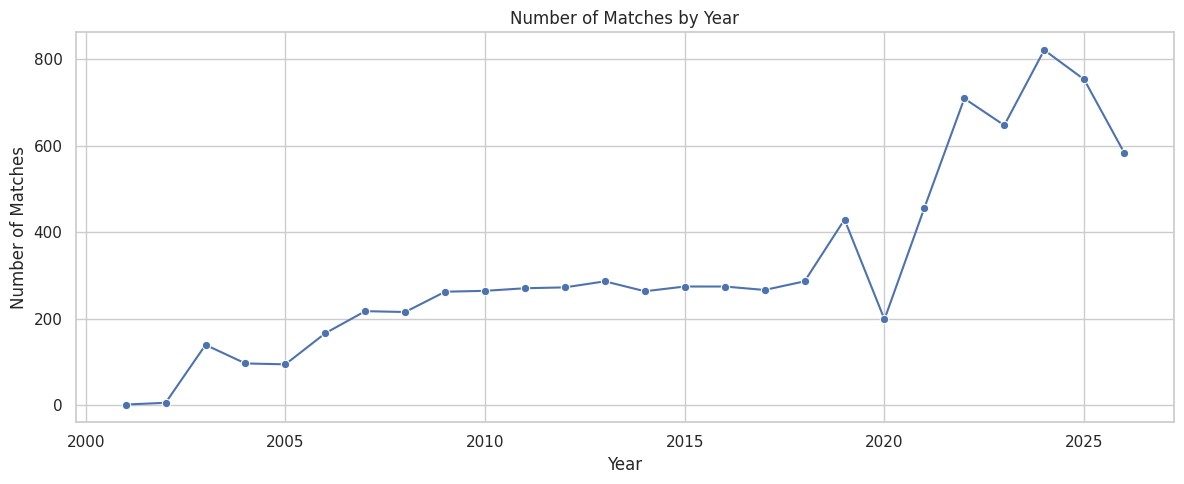

In [16]:
temp = df.copy()
temp["date"] = pd.to_datetime(temp["date"], errors="coerce")
year_counts = temp.dropna(subset=["date"])["date"].dt.year.value_counts().sort_index()

plt.figure(figsize=(12,5))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker="o")
plt.title("Number of Matches by Year")
plt.xlabel("Year"); plt.ylabel("Number of Matches")
plt.tight_layout(); plt.show()

In [17]:
OUTPUT = "/content/cricvision_eda_dataset.csv"
df.to_csv(OUTPUT, index=False)
print("Saved:", OUTPUT)

from google.colab import files
files.download(OUTPUT)

Saved: /content/cricvision_eda_dataset.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
def get_teams(info):
    teams = info.get("teams", [])
    return teams[0] if len(teams) > 0 else None, teams[1] if len(teams) > 1 else None

def get_toss(info):
    toss = info.get("toss", {})
    return toss.get("winner"), toss.get("decision")

def get_outcome(info):
    outcome = info.get("outcome", {})
    if outcome.get("winner"):
        return outcome.get("winner"), "winner"
    if outcome.get("result"):
        return None, outcome.get("result")
    if "draw" in outcome:
        return None, "draw"
    return None, "unknown"

def get_totals(match, team1, team2):
    totals = {team1: [0, 0], team2: [0, 0]}

    for innings in match.get("innings", []):
        team = innings.get("team")
        if team not in totals:
            continue

        for over in innings.get("overs", []):
            for delivery in over.get("deliveries", []):
                totals[team][0] += delivery.get("runs", {}).get("total", 0)

                for wicket in delivery.get("wickets", []):
                    kind = str(wicket.get("kind", "")).lower()
                    if kind not in ["retired hurt", "retired not out"]:
                        totals[team][1] += 1

    t1 = totals.get(team1, [0, 0])
    t2 = totals.get(team2, [0, 0])

    return t1[0], t2[0], t1[1], t2[1]

def parse_match(path, fmt):
    with open(path, "r", encoding="utf-8") as f:
        match = json.load(f)

    info = match.get("info", {})
    team1, team2 = get_teams(info)
    toss_winner, toss_decision = get_toss(info)
    winner, result = get_outcome(info)

    dates = info.get("dates", [])
    date = dates[0] if isinstance(dates, list) and dates else None

    r1, r2, w1, w2 = get_totals(match, team1, team2)

    return {
        "format": fmt,
        "date": date,
        "team1": team1,
        "team2": team2,
        "venue": info.get("venue"),
        "toss_winner": toss_winner,
        "toss_decision": toss_decision,
        "winner": winner,
        "result": result,
        "team1_runs": r1,
        "team2_runs": r2,
        "team1_wickets": w1,
        "team2_wickets": w2
    }

records = []

for fmt in ["TEST", "ODI", "T20", "IPL"]:
    json_files = list((DATA_DIR / fmt).rglob("*.json"))
    print(f"{fmt}: {len(json_files)} JSON files")

    for path in json_files:
        try:
            records.append(parse_match(path, fmt))
        except Exception as e:
            print("Skipped:", path.name, "|", e)

df = pd.DataFrame(records)

print("\nDataset Shape:", df.shape)
display(df.head())

TEST: 894 JSON files
ODI: 2571 JSON files
T20: 3539 JSON files
IPL: 1243 JSON files

Dataset Shape: (8247, 13)


,format,date,team1,team2,venue,toss_winner,toss_decision,winner,result,team1_runs,team2_runs,team1_wickets,team2_wickets
0,TEST,2015-07-03,Sri Lanka,Pakistan,Pallekele International Cricket Stadium,Pakistan,field,Pakistan,winner,591,597,20,13
1,TEST,2019-08-30,West Indies,India,"Sabina Park, Jamaica",West Indies,field,India,winner,327,584,20,14
2,TEST,2016-05-27,England,Sri Lanka,Riverside Ground,England,bat,England,winner,578,576,10,20
3,TEST,2018-11-24,Pakistan,New Zealand,Dubai International Cricket Stadium,Pakistan,bat,Pakistan,winner,418,402,5,20
4,TEST,2003-12-18,England,Sri Lanka,"Sinhalese Sports Club Ground, Colombo",England,bat,Sri Lanka,winner,413,628,20,8


In [19]:
print("Number of Records:", df.shape[0])
print("Number of Features:", df.shape[1])

print("\nFeatures:")
for col in df.columns:
    print("•", col)

print("\nRecords by Format:")
display(df["format"].value_counts())

Number of Records: 8247
Number of Features: 13

Features:
• format
• date
• team1
• team2
• venue
• toss_winner
• toss_decision
• winner
• result
• team1_runs
• team2_runs
• team1_wickets
• team2_wickets

Records by Format:


,count
format,
T20,3539
ODI,2571
IPL,1243
TEST,894


In [20]:
missing = df.isnull().sum().sort_values(ascending=False)

print("Missing Values")
display(missing.to_frame("Count"))

print("Duplicate Records:", df.duplicated().sum())

Missing Values


,Count
winner,438
date,0
team1,0
team2,0
format,0
venue,0
toss_winner,0
toss_decision,0
result,0
team1_runs,0


Duplicate Records: 0


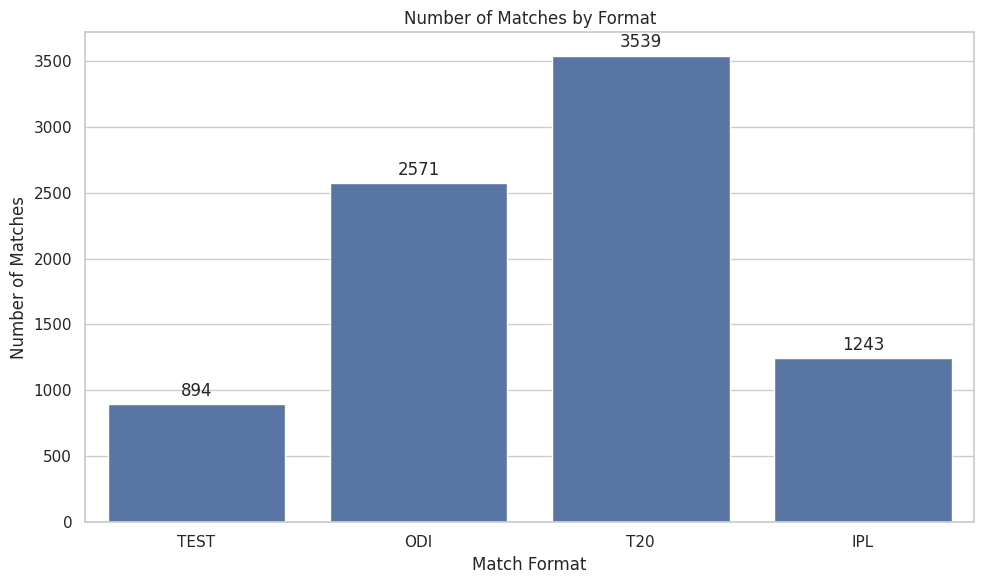

In [21]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df,
    x="format",
    order=["TEST", "ODI", "T20", "IPL"]
)

plt.title("Number of Matches by Format")
plt.xlabel("Match Format")
plt.ylabel("Number of Matches")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

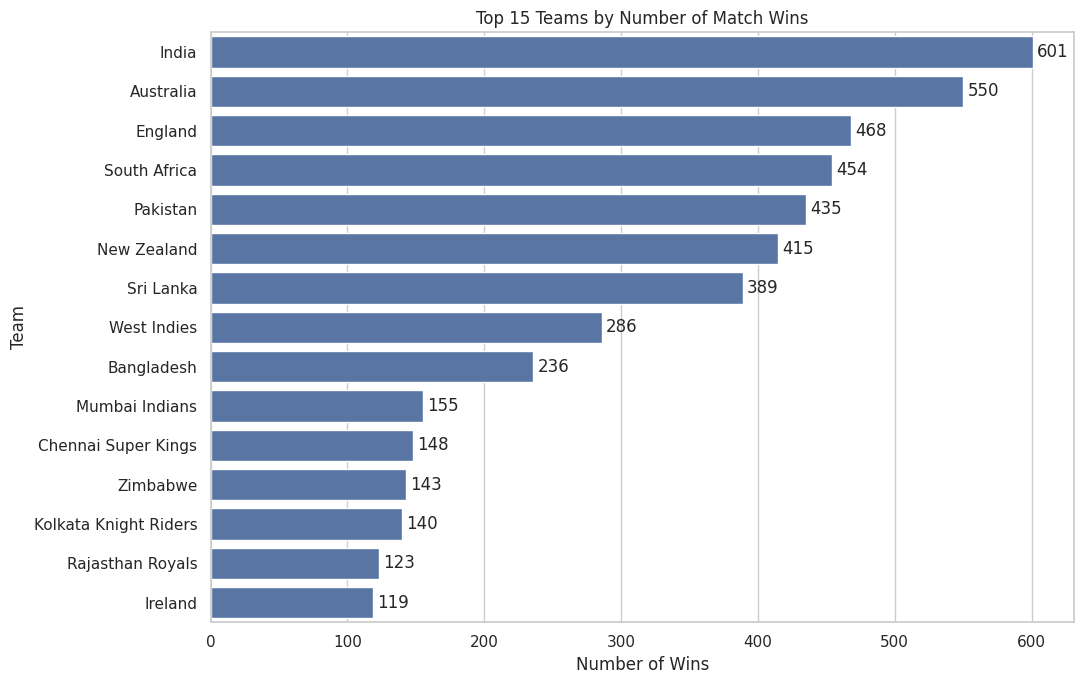

In [22]:
winner_counts = df["winner"].dropna().value_counts().head(15)

plt.figure(figsize=(11, 7))

ax = sns.barplot(
    x=winner_counts.values,
    y=winner_counts.index
)

plt.title("Top 15 Teams by Number of Match Wins")
plt.xlabel("Number of Wins")
plt.ylabel("Team")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

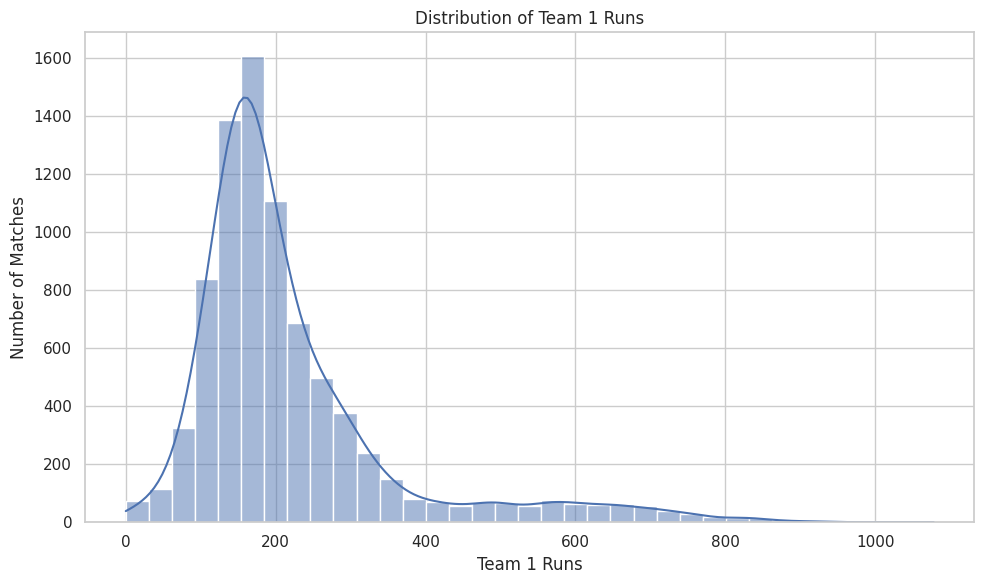

In [23]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="team1_runs",
    bins=35,
    kde=True
)

plt.title("Distribution of Team 1 Runs")
plt.xlabel("Team 1 Runs")
plt.ylabel("Number of Matches")

plt.tight_layout()
plt.show()

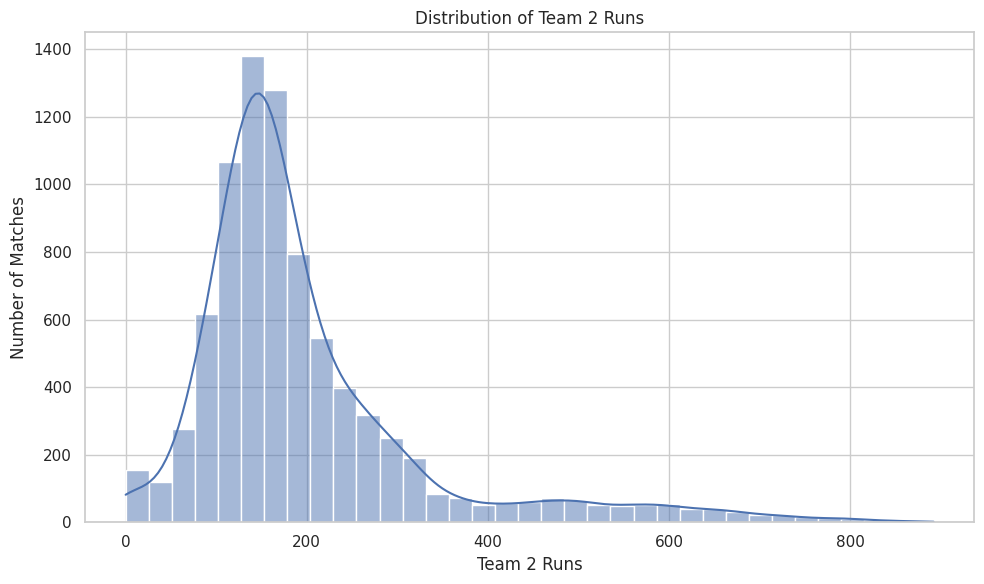

In [24]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="team2_runs",
    bins=35,
    kde=True
)

plt.title("Distribution of Team 2 Runs")
plt.xlabel("Team 2 Runs")
plt.ylabel("Number of Matches")

plt.tight_layout()
plt.show()

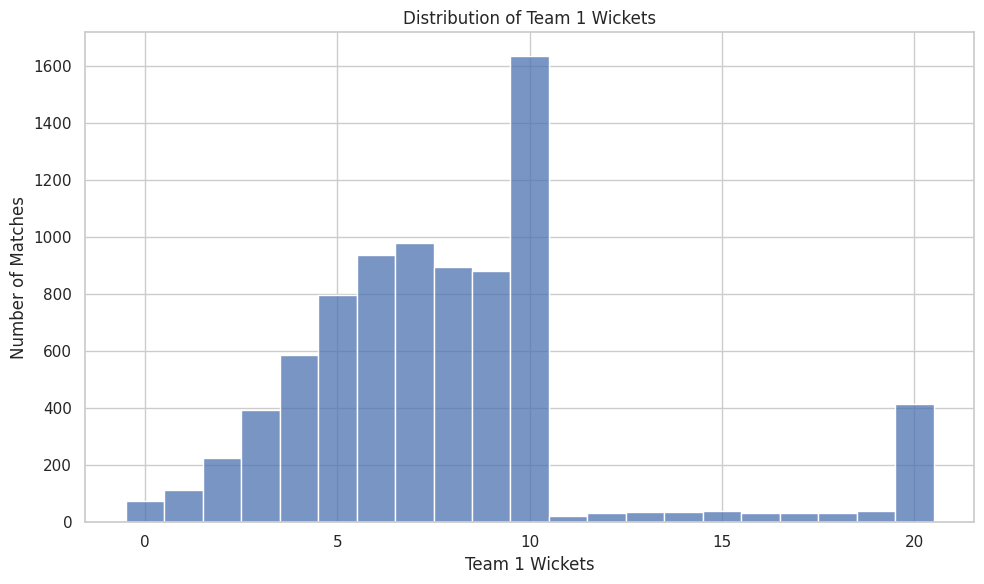

In [25]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="team1_wickets",
    bins=22,
    discrete=True
)

plt.title("Distribution of Team 1 Wickets")
plt.xlabel("Team 1 Wickets")
plt.ylabel("Number of Matches")

plt.tight_layout()
plt.show()

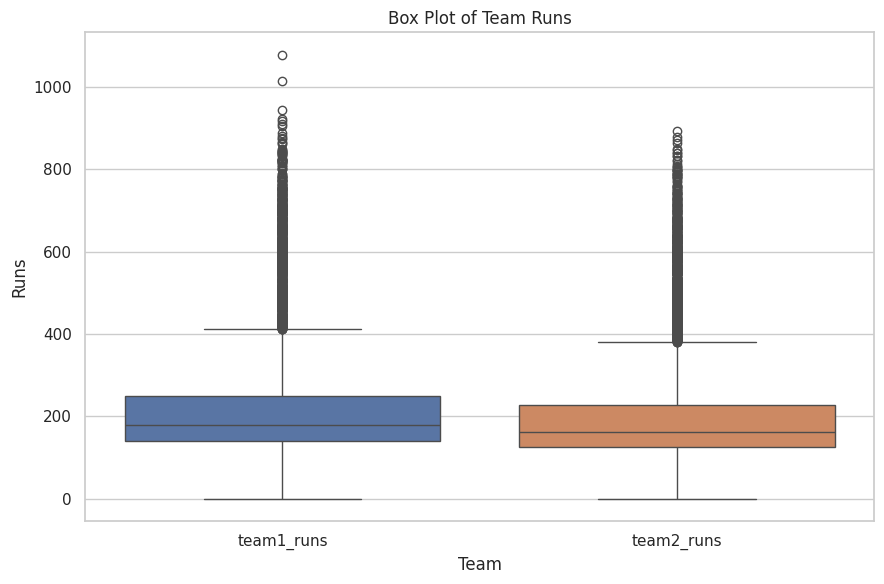

In [26]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df[["team1_runs", "team2_runs"]]
)

plt.title("Box Plot of Team Runs")
plt.xlabel("Team")
plt.ylabel("Runs")

plt.tight_layout()
plt.show()

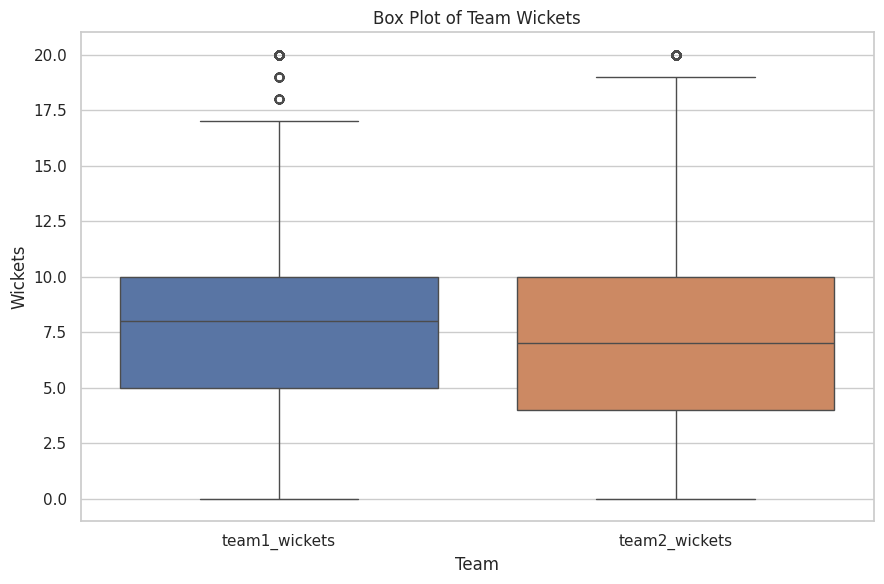

In [27]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df[["team1_wickets", "team2_wickets"]]
)

plt.title("Box Plot of Team Wickets")
plt.xlabel("Team")
plt.ylabel("Wickets")

plt.tight_layout()
plt.show()

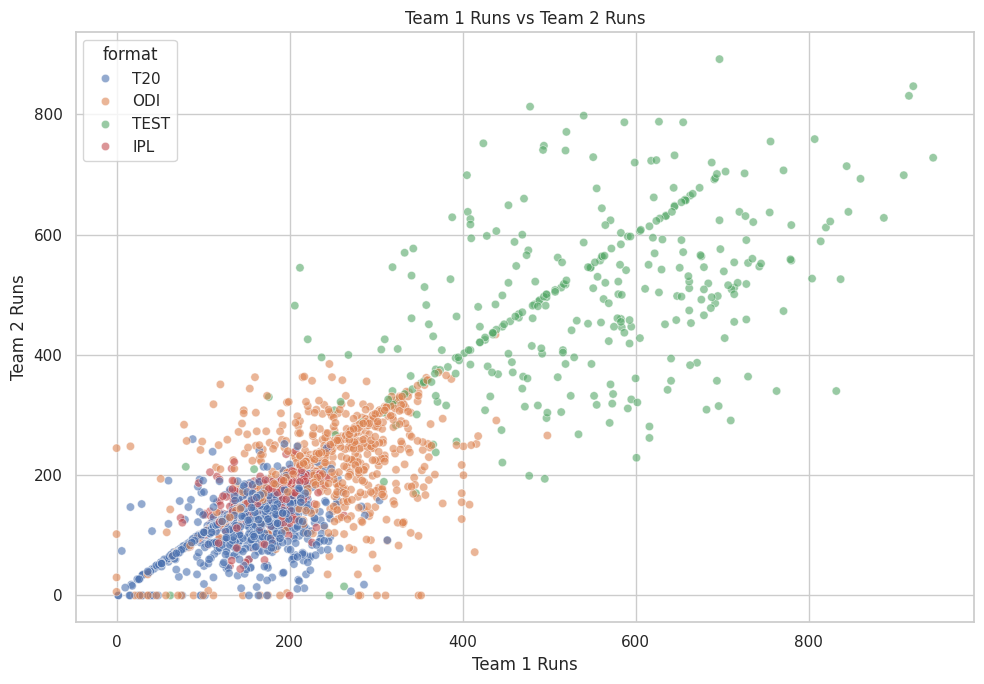

In [28]:
plot_df = df[
    (df["team1_runs"] > 0) |
    (df["team2_runs"] > 0)
].copy()

sample_df = plot_df.sample(
    min(3000, len(plot_df)),
    random_state=42
)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=sample_df,
    x="team1_runs",
    y="team2_runs",
    hue="format",
    alpha=0.6
)

plt.title("Team 1 Runs vs Team 2 Runs")
plt.xlabel("Team 1 Runs")
plt.ylabel("Team 2 Runs")

plt.tight_layout()
plt.show()

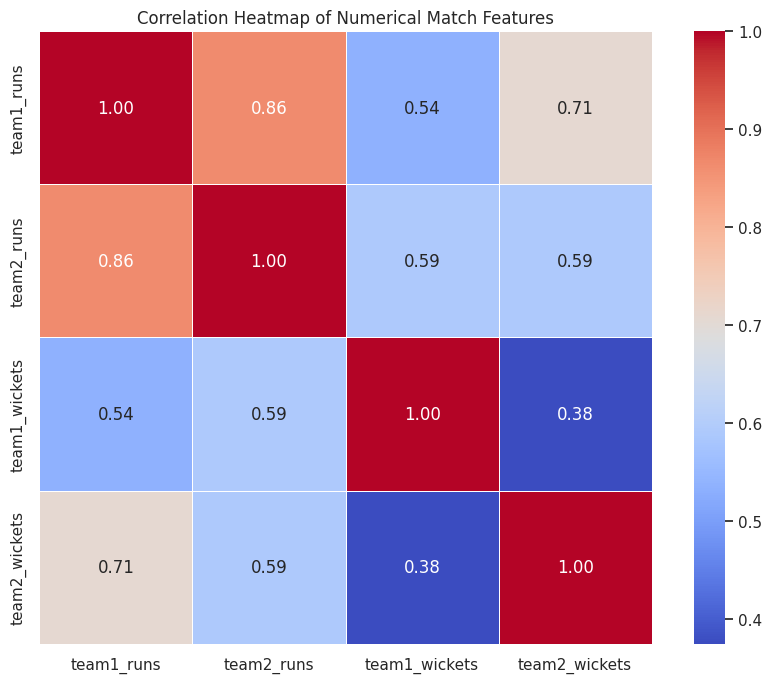

In [29]:
numeric_features = [
    "team1_runs",
    "team2_runs",
    "team1_wickets",
    "team2_wickets"
]

correlation = df[numeric_features].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap of Numerical Match Features")

plt.tight_layout()
plt.show()

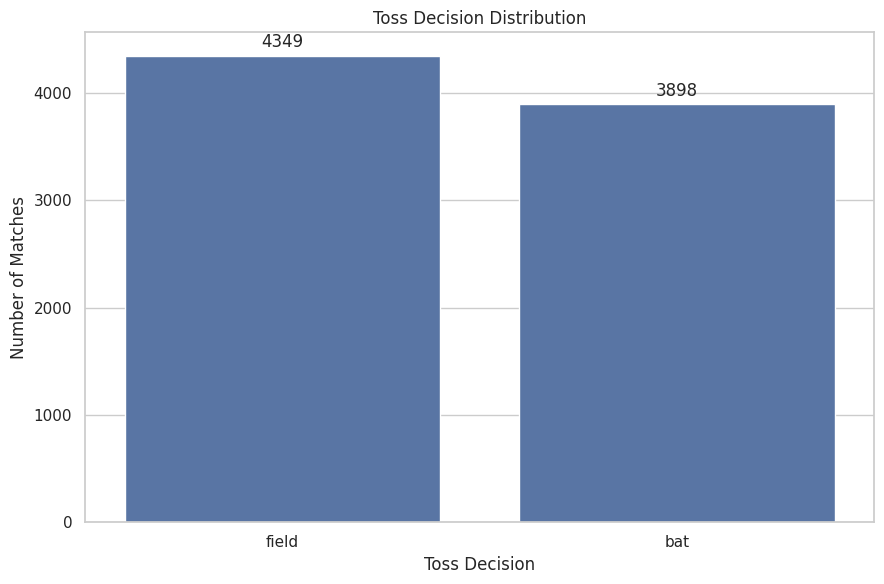

In [30]:
plt.figure(figsize=(9, 6))

ax = sns.countplot(
    data=df,
    x="toss_decision"
)

plt.title("Toss Decision Distribution")
plt.xlabel("Toss Decision")
plt.ylabel("Number of Matches")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

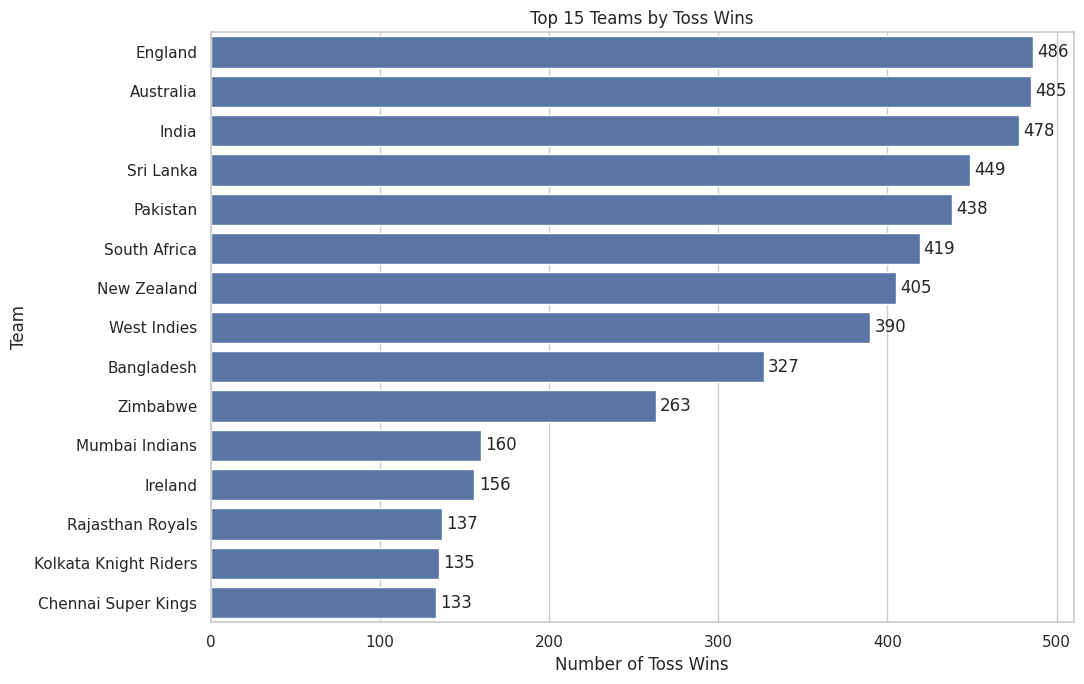

In [31]:
toss_winners = df["toss_winner"].dropna().value_counts().head(15)

plt.figure(figsize=(11, 7))

ax = sns.barplot(
    x=toss_winners.values,
    y=toss_winners.index
)

plt.title("Top 15 Teams by Toss Wins")
plt.xlabel("Number of Toss Wins")
plt.ylabel("Team")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

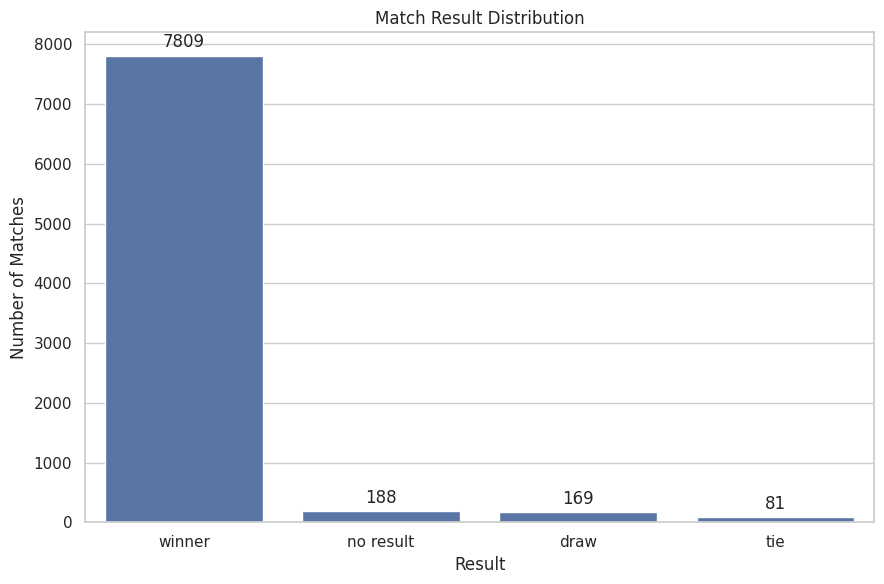

In [32]:
plt.figure(figsize=(9, 6))

ax = sns.countplot(
    data=df,
    x="result",
    order=df["result"].value_counts().index
)

plt.title("Match Result Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Matches")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

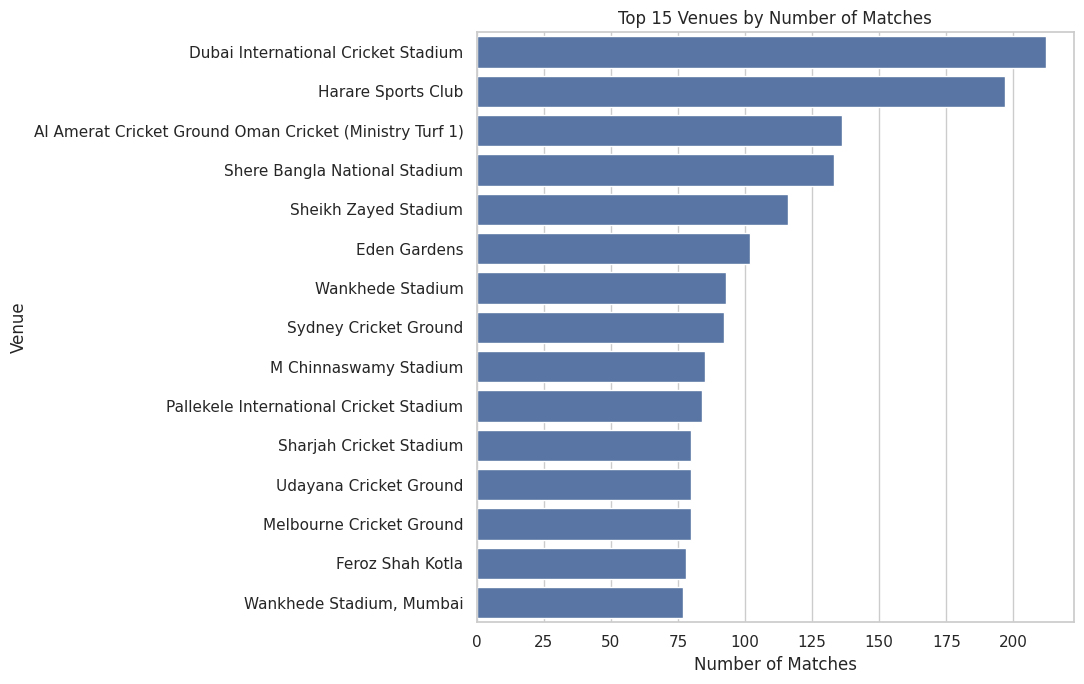

In [33]:
venue_counts = df["venue"].dropna().value_counts().head(15)

plt.figure(figsize=(11, 7))

sns.barplot(
    x=venue_counts.values,
    y=venue_counts.index
)

plt.title("Top 15 Venues by Number of Matches")
plt.xlabel("Number of Matches")
plt.ylabel("Venue")

plt.tight_layout()
plt.show()

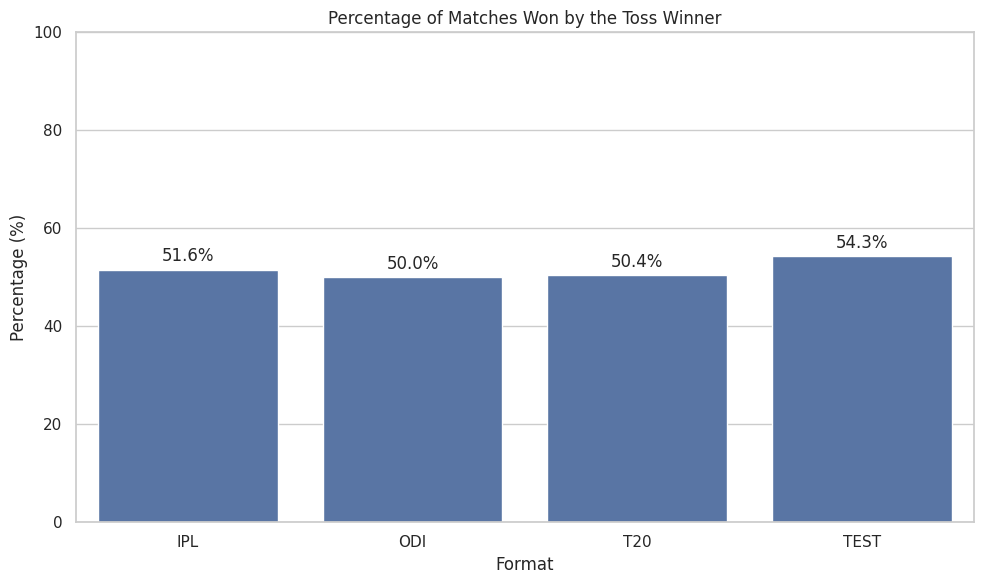

,Toss Winner Match Win %
format,
IPL,51.56
ODI,49.96
T20,50.38
TEST,54.34


In [34]:
toss_analysis = df.dropna(
    subset=["toss_winner", "winner"]
).copy()

toss_analysis["toss_winner_won"] = (
    toss_analysis["toss_winner"] ==
    toss_analysis["winner"]
)

toss_rate = (
    toss_analysis
    .groupby("format")["toss_winner_won"]
    .mean()
    .mul(100)
    .round(2)
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=toss_rate.index,
    y=toss_rate.values
)

plt.title("Percentage of Matches Won by the Toss Winner")
plt.xlabel("Format")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

display(toss_rate.to_frame("Toss Winner Match Win %"))

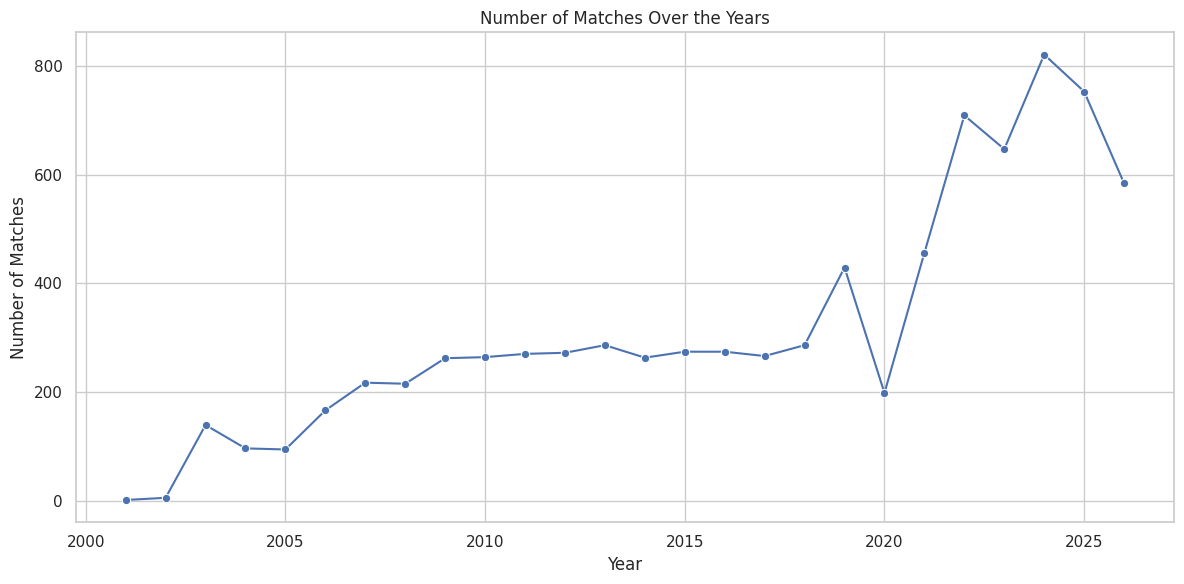

In [35]:
date_df = df.copy()
date_df["date"] = pd.to_datetime(
    date_df["date"],
    errors="coerce"
)

year_counts = (
    date_df.dropna(subset=["date"])
    .groupby(date_df["date"].dt.year)
    .size()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=year_counts.index,
    y=year_counts.values,
    marker="o"
)

plt.title("Number of Matches Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of Matches")

plt.tight_layout()
plt.show()

In [37]:
# ============================================================
# DOWNLOAD COMPLETE EDA REPORT AS PDF
# ============================================================

from matplotlib.backends.backend_pdf import PdfPages
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

PDF_PATH = "/content/CricVision_EDA_Report.pdf"

with PdfPages(PDF_PATH) as pdf:

    # --------------------------------------------------------
    # 1. TITLE PAGE
    # --------------------------------------------------------
    fig = plt.figure(figsize=(11.69, 8.27))
    plt.axis("off")

    plt.text(
        0.5, 0.62,
        "MATCH OUTCOME PREDICTION",
        ha="center",
        fontsize=28,
        fontweight="bold"
    )

    plt.text(
        0.5, 0.52,
        "Using Logistic Regression and Random Forest",
        ha="center",
        fontsize=22
    )

    plt.text(
        0.5, 0.40,
        "CricVision",
        ha="center",
        fontsize=20,
        fontweight="bold"
    )

    plt.text(
        0.5, 0.32,
        "Exploratory Data Analysis Report",
        ha="center",
        fontsize=16
    )

    plt.text(
        0.5, 0.22,
        f"Dataset: {len(df):,} match records | {df.shape[1]} raw features",
        ha="center",
        fontsize=12
    )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close()

    # --------------------------------------------------------
    # 2. MATCHES BY FORMAT — COUNT PLOT
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(11, 7))

    order = ["TEST", "ODI", "T20", "IPL"]

    sns.countplot(
        data=df,
        x="format",
        order=order,
        ax=ax
    )

    ax.set_title(
        "Number of Matches by Format",
        fontsize=18,
        fontweight="bold"
    )
    ax.set_xlabel("Match Format")
    ax.set_ylabel("Number of Matches")

    for container in ax.containers:
        ax.bar_label(container, padding=3)

    plt.tight_layout()
    pdf.savefig(fig)
    plt.close()

    # --------------------------------------------------------
    # 3. TOP TEAMS BY WINS — BAR CHART
    # --------------------------------------------------------
    wins = df["winner"].dropna().value_counts().head(15)

    fig, ax = plt.subplots(figsize=(11, 7))

    sns.barplot(
        x=wins.values,
        y=wins.index,
        ax=ax
    )

    ax.set_title(
        "Top 15 Teams by Number of Match Wins",
        fontsize=18,
        fontweight="bold"
    )
    ax.set_xlabel("Number of Wins")
    ax.set_ylabel("Team")

    for container in ax.containers:
        ax.bar_label(container, padding=3)

    plt.tight_layout()
    pdf.savefig(fig)
    plt.close()

    # --------------------------------------------------------
    # 4. HISTOGRAM — TEAM 1 RUNS
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(11, 7))

    sns.histplot(
        data=df,
        x="team1_runs",
        bins=35,
        kde=True,
        ax=ax
    )

    ax.set_title(
        "Distribution of Team 1 Runs",
        fontsize=18,
        fontweight="bold"
    )
    ax.set_xlabel("Team 1 Runs")
    ax.set_ylabel("Number of Matches")

    plt.tight_layout()
    pdf.savefig(fig)
    plt.close()

    # --------------------------------------------------------
    # 5. HISTOGRAM — TEAM 2 RUNS
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(11, 7))

    sns.histplot(
        data=df,
        x="team2_runs",
        bins=35,
        kde=True,
        ax=ax
    )

    ax.set_title(
        "Distribution of Team 2 Runs",
        fontsize=18,
        fontweight="bold"
    )
    ax.set_xlabel("Team 2 Runs")
    ax.set_ylabel("Number of Matches")

    plt.tight_layout()
    pdf.savefig(fig)
    plt.close()

    # --------------------------------------------------------
    # 6. BOX PLOT — RUNS
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(11, 7))

    sns.boxplot(
        data=df[["team1_runs", "team2_runs"]],
        ax=ax
    )

    ax.set_title(
        "Box Plot of Team Runs",
        fontsize=18,
        fontweight="bold"
    )
    ax.set_xlabel("Team")
    ax.set_ylabel("Runs")

    plt.tight_layout()
    pdf.savefig(fig)
    plt.close()

    # --------------------------------------------------------
    # 7. BOX PLOT — WICKETS
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(11, 7))

    sns.boxplot(
        data=df[["team1_wickets", "team2_wickets"]],
        ax=ax
    )

    ax.set_title(
        "Box Plot of Team Wickets",
        fontsize=18,
        fontweight="bold"
    )
    ax.set_xlabel("Team")
    ax.set_ylabel("Wickets")

    plt.tight_layout()
    pdf.savefig(fig)
    plt.close()

    # --------------------------------------------------------
    # 8. SCATTER PLOT
    # --------------------------------------------------------
    plot_df = df[
        (df["team1_runs"] > 0) |
        (df["team2_runs"] > 0)
    ].copy()

    sample_df = plot_df.sample(
        min(3000, len(plot_df)),
        random_state=42
    )

    fig, ax = plt.subplots(figsize=(11, 7))

    sns.scatterplot(
        data=sample_df,
        x="team1_runs",
        y="team2_runs",
        hue="format",
        alpha=0.6,
        ax=ax
    )

    ax.set_title(
        "Team 1 Runs vs Team 2 Runs",
        fontsize=18,
        fontweight="bold"
    )
    ax.set_xlabel("Team 1 Runs")
    ax.set_ylabel("Team 2 Runs")

    plt.tight_layout()
    pdf.savefig(fig)
    plt.close()

    # --------------------------------------------------------
    # 9. CORRELATION HEATMAP
    # --------------------------------------------------------
    numerical_columns = [
        "team1_runs",
        "team2_runs",
        "team1_wickets",
        "team2_wickets"
    ]

    correlation = df[numerical_columns].corr()

    fig, ax = plt.subplots(figsize=(10, 8))

    sns.heatmap(
        correlation,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        linewidths=0.5,
        square=True,
        ax=ax
    )

    ax.set_title(
        "Correlation Heatmap of Numerical Match Features",
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout()
    pdf.savefig(fig)
    plt.close()

    # --------------------------------------------------------
    # 10. TOSS DECISION — COUNT PLOT
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(11, 7))

    sns.countplot(
        data=df,
        x="toss_decision",
        ax=ax
    )

    ax.set_title(
        "Toss Decision Distribution",
        fontsize=18,
        fontweight="bold"
    )
    ax.set_xlabel("Toss Decision")
    ax.set_ylabel("Number of Matches")

    for container in ax.containers:
        ax.bar_label(container, padding=3)

    plt.tight_layout()
    pdf.savefig(fig)
    plt.close()

    # --------------------------------------------------------
    # 11. TOP TOSS-WINNING TEAMS
    # --------------------------------------------------------
    toss_winners = (
        df["toss_winner"]
        .dropna()
        .value_counts()
        .head(15)
    )

    fig, ax = plt.subplots(figsize=(11, 7))

    sns.barplot(
        x=toss_winners.values,
        y=toss_winners.index,
        ax=ax
    )

    ax.set_title(
        "Top 15 Teams by Toss Wins",
        fontsize=18,
        fontweight="bold"
    )
    ax.set_xlabel("Number of Toss Wins")
    ax.set_ylabel("Team")

    plt.tight_layout()
    pdf.savefig(fig)
    plt.close()

    # --------------------------------------------------------
    # 12. MATCH RESULT — COUNT PLOT
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(11, 7))

    sns.countplot(
        data=df,
        x="result",
        order=df["result"].value_counts().index,
        ax=ax
    )

    ax.set_title(
        "Match Result Distribution",
        fontsize=18,
        fontweight="bold"
    )
    ax.set_xlabel("Result")
    ax.set_ylabel("Number of Matches")

    for container in ax.containers:
        ax.bar_label(container, padding=3)

    plt.tight_layout()
    pdf.savefig(fig)
    plt.close()

    # --------------------------------------------------------
    # 13. TOP VENUES
    # --------------------------------------------------------
    venues = (
        df["venue"]
        .dropna()
        .value_counts()
        .head(15)
    )

    fig, ax = plt.subplots(figsize=(11, 8))

    sns.barplot(
        x=venues.values,
        y=venues.index,
        ax=ax
    )

    ax.set_title(
        "Top 15 Venues by Number of Matches",
        fontsize=18,
        fontweight="bold"
    )
    ax.set_xlabel("Number of Matches")
    ax.set_ylabel("Venue")

    plt.tight_layout()
    pdf.savefig(fig)
    plt.close()

    # --------------------------------------------------------
    # 14. TOSS WINNER VS MATCH WINNER
    # --------------------------------------------------------
    toss_analysis = df.dropna(
        subset=["toss_winner", "winner"]
    ).copy()

    toss_analysis["toss_winner_won"] = (
        toss_analysis["toss_winner"] ==
        toss_analysis["winner"]
    )

    toss_rate = (
        toss_analysis
        .groupby("format")["toss_winner_won"]
        .mean()
        .mul(100)
    )

    fig, ax = plt.subplots(figsize=(11, 7))

    sns.barplot(
        x=toss_rate.index,
        y=toss_rate.values,
        ax=ax
    )

    ax.set_title(
        "Percentage of Matches Won by the Toss Winner",
        fontsize=18,
        fontweight="bold"
    )
    ax.set_xlabel("Format")
    ax.set_ylabel("Percentage (%)")
    ax.set_ylim(0, 100)

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=3
        )

    plt.tight_layout()
    pdf.savefig(fig)
    plt.close()

    # --------------------------------------------------------
    # 15. MATCHES OVER TIME
    # --------------------------------------------------------
    date_df = df.copy()

    date_df["date"] = pd.to_datetime(
        date_df["date"],
        errors="coerce"
    )

    year_counts = (
        date_df
        .dropna(subset=["date"])
        .groupby(date_df["date"].dt.year)
        .size()
    )

    fig, ax = plt.subplots(figsize=(12, 7))

    sns.lineplot(
        x=year_counts.index,
        y=year_counts.values,
        marker="o",
        ax=ax
    )

    ax.set_title(
        "Number of Matches Over the Years",
        fontsize=18,
        fontweight="bold"
    )
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of Matches")

    plt.tight_layout()
    pdf.savefig(fig)
    plt.close()

print("EDA REPORT CREATED SUCCESSFULLY!")
print("File:", PDF_PATH)

# Download the complete PDF report
files.download(PDF_PATH)

EDA REPORT CREATED SUCCESSFULLY!
File: /content/CricVision_EDA_Report.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>